In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import sys
from pathlib import Path

# Ruta raíz del proyecto en Drive
PROJECT_PATH = Path("/content/drive/MyDrive/proyecto_AAIII_02_diffusion_models")

# Carpetas principales
NOTEBOOKS_DIR = PROJECT_PATH / "notebooks"
SRC_DIR = PROJECT_PATH / "src"
CHECKPOINTS_DIR = PROJECT_PATH / "checkpoints"
RESULTS_DIR = PROJECT_PATH / "results"

# Añadir src al path para poder importar los .py
sys.path.insert(0, str(SRC_DIR))

# Crear carpetas si no existen
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_PATH =", PROJECT_PATH)
print("SRC_DIR =", SRC_DIR)
print("CHECKPOINTS_DIR =", CHECKPOINTS_DIR)
print("RESULTS_DIR =", RESULTS_DIR)

PROJECT_PATH = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models
SRC_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/src
CHECKPOINTS_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints
RESULTS_DIR = /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/results


# Training a Brownian-motion diffusion model on MNIST

This auxiliary notebook is used to train a higher-quality score-based diffusion model on MNIST using the Brownian motion (variance exploding) forward process. The trained checkpoint will later be reused in the main notebook for sample generation with the Euler–Maruyama integrator.

In [ ]:
import os
from functools import partial

import torch
from torch.optim import Adam
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor
from tqdm.notebook  import trange

from score_model_cifar import ScoreNetCIFAR
from diffusion_utilities import plot_image_grid, plot_image_evolution
from diffusion_process import euler_maruyama_integrator
from bm_utils import (
    bm_sigma_t,
    build_bm_diffusion_process,
    sample_bm_euler_maruyama,
)

In [ ]:
# Reproducibility
_ = torch.manual_seed(123)

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Paths
checkpoint_path = CHECKPOINTS_DIR / "bm_cifar_cats_best.pth"
print("Checkpoint path:", checkpoint_path)

Device: cuda
Checkpoint path: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/bm_cifar_cats_best.pth


In [ ]:
data = datasets.CIFAR10(
  root='data',
  train=True,
  download=True,
  transform=ToTensor()
)
CAT_CLASS = 3
targets_tensor = torch.tensor(data.targets)
indices_cat = torch.where(targets_tensor == CAT_CLASS)[0]
data_train = Subset(data, indices_cat)

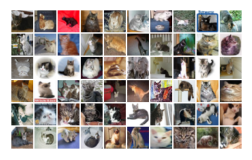

In [ ]:
n_rows = 6
n_cols = 10

_ = plot_image_grid(
    images=[data_train[i][0] for i in range(n_rows * n_cols)],
    figsize=(3, 3),
    n_rows=n_rows,
    n_cols=n_cols,
)

In [ ]:
batch_size = 64

data_loader = DataLoader(
    data_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=torch.get_num_threads(),
)

In [ ]:
sigma = 25.0
diffusion_process = build_bm_diffusion_process(sigma=sigma)

In [ ]:
from functools import partial

score_model = torch.nn.DataParallel(
    ScoreNetCIFAR(
        marginal_prob_std=partial(bm_sigma_t, sigma=sigma)
    )
).to(device)

In [ ]:
checkpoint = torch.load(checkpoint_path, map_location=device)
score_model.load_state_dict(checkpoint)
score_model.eval()

print("Checkpoint loaded correctly from:", checkpoint_path)

Checkpoint loaded correctly from: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/bm_cifar_cats_best.pth


In [ ]:
learning_rate = 1.0e-4
optimizer = Adam(score_model.parameters(), lr=learning_rate)

In [ ]:
n_epochs = 300
best_loss = float("inf")

tqdm_epoch = trange(n_epochs)

for epoch in tqdm_epoch:
    score_model.train()
    avg_loss = 0.0
    num_items = 0

    for x, _ in data_loader:
        x = x.to(device)

        loss = diffusion_process.loss_function(score_model, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        avg_loss += loss.item() * x.shape[0]
        num_items += x.shape[0]

    epoch_loss = avg_loss / num_items
    tqdm_epoch.set_description(f"Average Loss: {epoch_loss:8.5f}")

    # Save the best checkpoint
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        torch.save(score_model.state_dict(), checkpoint_path)

  0%|          | 0/300 [00:00<?, ?it/s]

In [ ]:
score_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
score_model.eval()

print("Loaded checkpoint:", checkpoint_path)

Loaded checkpoint: /content/drive/MyDrive/proyecto_AAIII_02_diffusion_models/checkpoints/bm_cifar_cats_best.pth


In [ ]:
n_images = 16

times, synthetic_images_t = sample_bm_euler_maruyama(
    score_model=score_model,
    sigma=sigma,
    n_images=n_images,
    image_shape=(3, 32, 32),
    T=1.0,
    t_end=1.0e-3,
    n_steps=1000,
    device=device,
)

print(synthetic_images_t.shape)

torch.Size([16, 3, 32, 32, 1001])


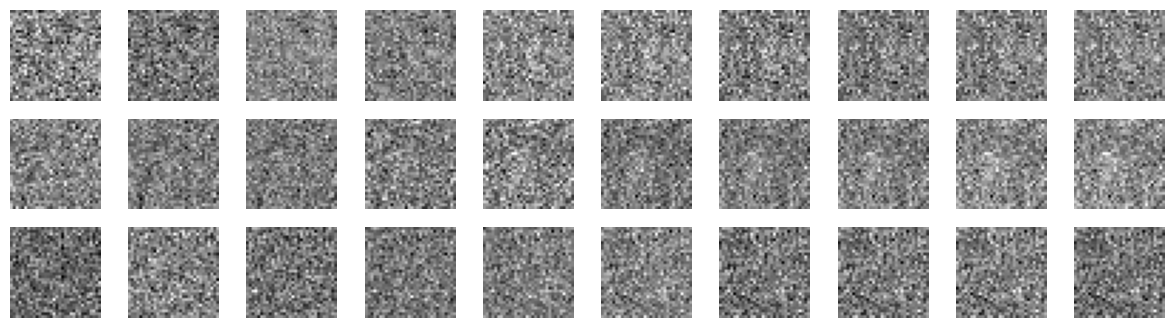

In [ ]:
_ = plot_image_evolution(
    images=synthetic_images_t.cpu(),
    n_images=3,
    n_intermediate_steps=[0, 100, 200, 300, 400, 450, 470, 480, 490, 500],
    figsize=(15, 4),
)

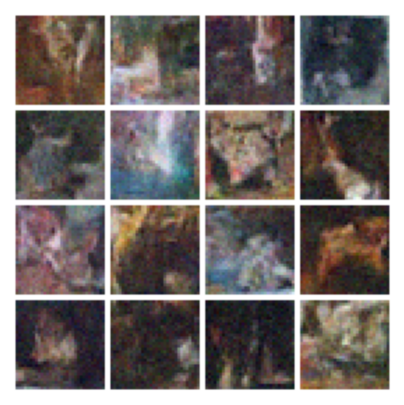

In [ ]:
final_images = synthetic_images_t[..., -1].cpu()

_ = plot_image_grid(
    images=[final_images[i] for i in range(n_images)],
    figsize=(5, 5),
    n_rows=4,
    n_cols=4,
    normalize=True,
)